In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from pathlib import Path

In [2]:
# Config
DATA_PATH = Path("/home/colmanok/Code/QM9/data/archive")
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
TRAIN_SPLIT = 0.7
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Utils
atomic_numbers = {
    "H": 1, "C": 6, "N": 7, "O": 8, "F": 9
}

In [4]:
# Parser .xyz
def safe_float(x):
    return float(x.replace("*^", "e"))

def parse_xyz(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    n_atoms = int(lines[0])
    comment = lines[1]

    values = comment.split()

    try:
        U0 = float(values[-5])  # 🔥 clave
    except:
        U0 = 0.0

    Z = []
    R = []

    for line in lines[2:2+n_atoms]:
        parts = line.split()
        symbol = parts[0]

        x, y, z = [safe_float(v) for v in parts[1:4]]

        Z.append(atomic_numbers[symbol])
        R.append([x, y, z])

    return np.array(Z, dtype=np.float32), np.array(R, dtype=np.float32), U0

In [5]:
# Calcular mean y std de U0 antes de construir el dataset
all_U0 = np.array([parse_xyz(f)[2] for f in DATA_PATH.glob("*.xyz")])

U0_mean = all_U0.mean()
U0_std  = all_U0.std()

print("Min U0:", all_U0.min())
print("Max U0:", all_U0.max())
print("U0 mean:", U0_mean)
print("U0 std: ", U0_std)

Min U0: -714.568061
Max U0: -40.47893
U0 mean: -411.54398452817713
U0 std:  40.06008080484784


In [6]:
# Dataset
class QM9Dataset(Dataset):
    def __init__(self, folder, mean, std):
        self.files = list(folder.glob("*.xyz"))
        self.mean  = mean
        self.std   = std

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        Z, R, U0 = parse_xyz(self.files[idx])

        U0_norm = (U0 - self.mean) / self.std  # 🔥 campo separado, U0 físico intacto

        return {
            "Z":       torch.tensor(Z),
            "R":       torch.tensor(R),
            "U0":      torch.tensor(U0,      dtype=torch.float32),  # valor físico (Hartree)
            "U0_norm": torch.tensor(U0_norm, dtype=torch.float32),  # normalizado (Z-score)
        }

In [7]:
# Collate (para batch variable)
def collate_fn(batch):
    return batch

In [8]:
# Modelo Kernel
class KernelModel(nn.Module):
    def __init__(self, hidden_dim=64, max_Z=10):
        super().__init__()

        # energía por átomo
        self.embedding = nn.Embedding(max_Z, 1)

        # kernel de interacción
        self.mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, batch):
        outputs = []

        for mol in batch:
            Z = mol["Z"].long().to(DEVICE)
            R = mol["R"].to(DEVICE)

            n = Z.shape[0]

            # término atómico
            atom_energy = self.embedding(Z).sum()

            # distancias
            diff = R.unsqueeze(1) - R.unsqueeze(0)
            dist = torch.norm(diff, dim=-1) + 1e-8

            # máscara i < j
            mask = torch.triu(torch.ones_like(dist), diagonal=1)

            rij = dist[mask == 1].unsqueeze(-1)
            Zi  = Z.unsqueeze(1).expand(n, n)[mask == 1]
            Zj  = Z.unsqueeze(0).expand(n, n)[mask == 1]

            # kernel
            K = self.mlp(rij).squeeze(-1)

            interaction = torch.sum(Zi * Zj * K)

            energy = atom_energy + interaction

            outputs.append(energy)

        return torch.stack(outputs)

In [9]:
# Modelo Kernel Flexible
class KernelModelFlexible(nn.Module):
    def __init__(self, hidden_dim=64, max_Z=10):
        super().__init__()

        self.embedding = nn.Embedding(max_Z, 1)

        self.mlp = nn.Sequential(
            nn.Linear(3, hidden_dim),  # Zi, Zj, rij
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, batch):
        outputs = []

        for mol in batch:
            Z = mol["Z"].long().to(DEVICE)
            R = mol["R"].to(DEVICE)

            n = Z.shape[0]

            # término atómico
            atom_energy = self.embedding(Z).sum()

            # distancias
            diff = R.unsqueeze(1) - R.unsqueeze(0)
            dist = torch.norm(diff, dim=-1) + 1e-8

            # máscara i < j
            mask = torch.triu(torch.ones_like(dist), diagonal=1)

            rij = dist[mask == 1]
            Zi  = Z.unsqueeze(1).expand(n, n)[mask == 1].float()
            Zj  = Z.unsqueeze(0).expand(n, n)[mask == 1].float()

            # normalización inputs
            Zi  = Zi  / 10.0
            Zj  = Zj  / 10.0
            rij = rij / 5.0

            pair_input = torch.stack([Zi, Zj, rij], dim=1)

            K = self.mlp(pair_input).squeeze(-1)

            interaction = torch.sum(K)

            energy = atom_energy + interaction

            outputs.append(energy)

        return torch.stack(outputs)

In [27]:
# Expansión en base Gaussiana (RBF)
class GaussianBasis(nn.Module):
    def __init__(self, r_min=0.0, r_max=5.0, n_basis=64):
        super().__init__()

        self.register_buffer("centers", torch.linspace(r_min, r_max, n_basis))
        self.gamma = 0.5 / ((r_max - r_min) / n_basis) ** 2

    def forward(self, r):
        # r: (n_pairs,) → (n_pairs, n_basis)
        return torch.exp(-self.gamma * (r.unsqueeze(-1) - self.centers) ** 2)

In [28]:
# Bloque de Interacción SchNet
class InteractionBlock(nn.Module):
    def __init__(self, hidden_dim=128, n_basis=64):
        super().__init__()

        # transforma el estado del átomo j antes de pasar el mensaje
        self.atomwise_pre = nn.Linear(hidden_dim, hidden_dim)

        # filtro continuo: de RBF a hidden_dim
        self.filter_mlp = nn.Sequential(
            nn.Linear(n_basis, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # transformación final tras agregar mensajes
        self.atomwise_post = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x, rbf, idx_i, idx_j):
        # x:     (n_atoms, hidden_dim)  — estados atómicos
        # rbf:   (n_pairs, n_basis)     — expansión gaussiana de r_ij
        # idx_i: (n_pairs,)             — índice átomo central
        # idx_j: (n_pairs,)             — índice átomo vecino

        # mensaje desde j: estado de j transformado, modulado por el filtro de distancia
        W   = self.filter_mlp(rbf)                       # (n_pairs, hidden_dim)
        msg = self.atomwise_pre(x[idx_j]) * W            # (n_pairs, hidden_dim)

        # agregar mensajes en cada átomo i
        agg = torch.zeros_like(x)
        agg.index_add_(0, idx_i, msg)                    # (n_atoms, hidden_dim)

        # transformación post-agregación con residual
        return x + self.atomwise_post(agg)

In [29]:
# Modelo SchNet
class SchNet(nn.Module):
    def __init__(self, hidden_dim=128, n_basis=64, n_interactions=3, r_cutoff=5.0, max_Z=10):
        super().__init__()

        self.r_cutoff = r_cutoff

        # embedding inicial por número atómico
        self.embedding = nn.Embedding(max_Z, hidden_dim)

        # expansión gaussiana de distancias
        self.rbf = GaussianBasis(r_min=0.0, r_max=r_cutoff, n_basis=n_basis)

        # capas de interacción
        self.interactions = nn.ModuleList([
            InteractionBlock(hidden_dim, n_basis)
            for _ in range(n_interactions)
        ])

        # readout: estado atómico → contribución escalar
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, batch):
        outputs = []

        for mol in batch:
            Z = mol["Z"].long().to(DEVICE)
            R = mol["R"].to(DEVICE)

            n = Z.shape[0]

            # estado inicial
            x = self.embedding(Z)                        # (n_atoms, hidden_dim)

            # distancias entre todos los pares
            diff = R.unsqueeze(1) - R.unsqueeze(0)       # (n, n, 3)
            dist = torch.norm(diff, dim=-1)              # (n, n)

            # pares dentro del cutoff, excluyendo diagonal (i != j)
            mask = (dist < self.r_cutoff) & (dist > 0)
            idx_i, idx_j = mask.nonzero(as_tuple=True)  # (n_pairs,), (n_pairs,)
            rij = dist[idx_i, idx_j]                     # (n_pairs,)

            # expansión gaussiana
            rbf = self.rbf(rij)                          # (n_pairs, n_basis)

            # capas de interacción
            for interaction in self.interactions:
                x = interaction(x, rbf, idx_i, idx_j)

            # readout y suma sobre átomos
            energy = self.readout(x).sum()

            outputs.append(energy)

        return torch.stack(outputs)

In [10]:
# Entrenamiento
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()

    train_losses = []
    test_losses  = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            preds   = model(batch)
            targets = torch.stack([m["U0_norm"] for m in batch]).to(DEVICE)  # 🔥 normalizado

            loss = loss_fn(preds, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        # eval
        model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in test_loader:
                preds   = model(batch)
                targets = torch.stack([m["U0_norm"] for m in batch]).to(DEVICE)  # 🔥 normalizado

                loss = loss_fn(preds, targets)
                total_loss += loss.item()

        test_loss = total_loss / len(test_loader)
        test_losses.append(test_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Test={test_loss:.4f}")

    return model, train_losses, test_losses

In [11]:
# Evaluación
def evaluate_model(model, loader, mean, std):
    model.eval()

    preds_list   = []
    targets_list = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico, no requiere desnormalizar

            preds_list.append(preds.cpu())
            targets_list.append(targets.cpu())

    preds   = torch.cat(preds_list).numpy()
    targets = torch.cat(targets_list).numpy()

    # desnormalizar solo las predicciones
    preds = preds * std + mean

    mae = np.mean(np.abs(preds - targets))

    return mae

In [12]:
# Load Dataset — una sola vez, con estadísticas ya calculadas
dataset = QM9Dataset(DATA_PATH, mean=U0_mean, std=U0_std)

train_size = int(TRAIN_SPLIT * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 93719 | Test: 40166


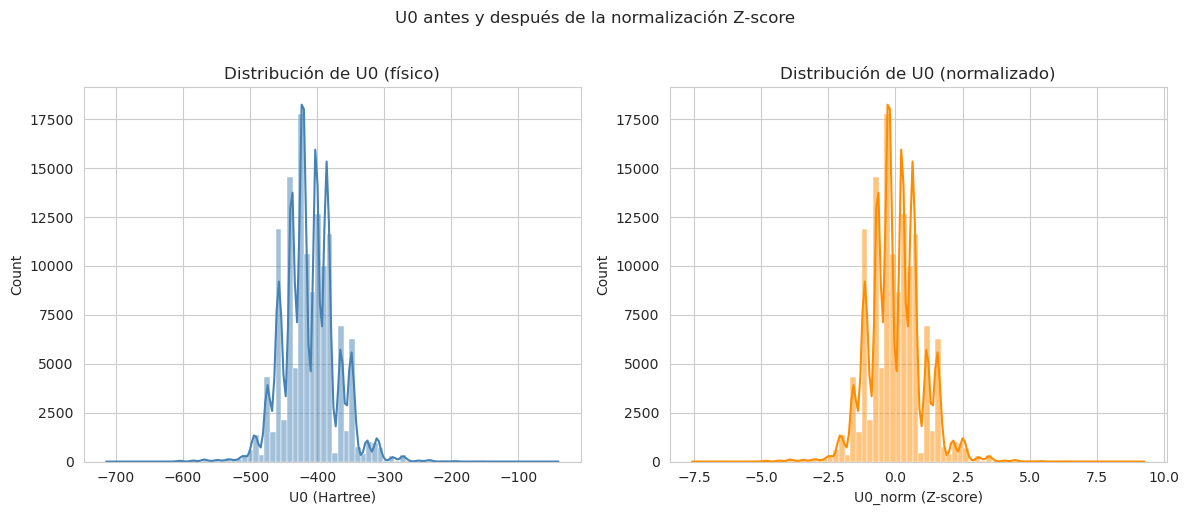

In [24]:
# Distribución de U0 físico y normalizado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(all_U0, bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de U0 (físico)")
axes[0].set_xlabel("U0 (Hartree)")
axes[0].set_ylabel("Count")

U0_normalized = (all_U0 - U0_mean) / U0_std
sns.histplot(U0_normalized, bins=80, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de U0 (normalizado)")
axes[1].set_xlabel("U0_norm (Z-score)")
axes[1].set_ylabel("Count")

plt.suptitle("U0 antes y después de la normalización Z-score", y=1.02)
plt.tight_layout()
plt.show()

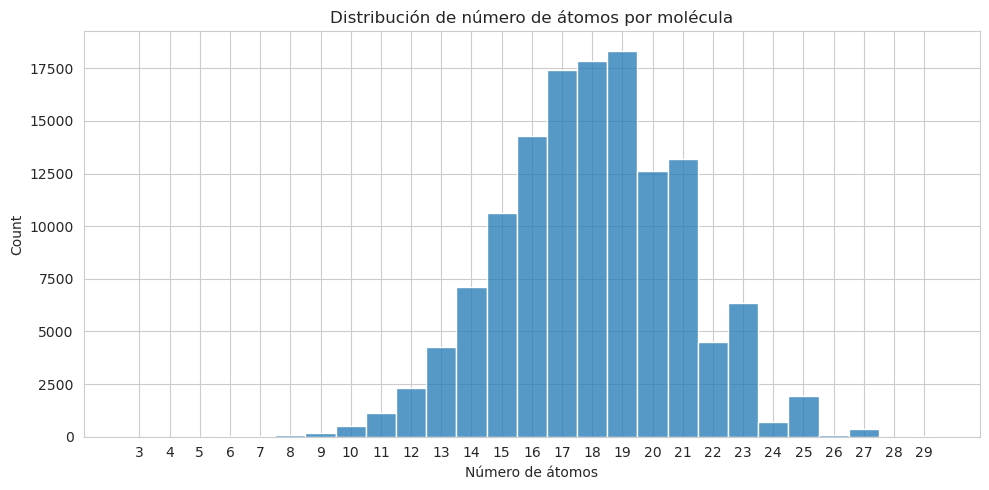

Min: 3 | Max: 29 | Mean: 17.98 | Std: 2.95


In [25]:
# Distribución de frecuencia de número de átomos por molécula
atom_counts = np.array([len(parse_xyz(f)[0]) for f in dataset.files])

plt.figure(figsize=(10, 5))
sns.histplot(atom_counts, bins=np.arange(atom_counts.min(), atom_counts.max() + 2) - 0.5, kde=False)
plt.title("Distribución de número de átomos por molécula")
plt.xlabel("Número de átomos")
plt.ylabel("Count")
plt.xticks(range(atom_counts.min(), atom_counts.max() + 1))
plt.tight_layout()
plt.show()

print(f"Min: {atom_counts.min()} | Max: {atom_counts.max()} | Mean: {atom_counts.mean():.2f} | Std: {atom_counts.std():.2f}")

In [13]:
# Modelo A (original)
model_A = KernelModel()
model_A, train_A, test_A = train_model(model_A, train_loader, test_loader, epochs=15, lr=5e-4)

Epoch 1: Train=1349.1615 | Test=2.6708
Epoch 2: Train=2.5229 | Test=1.1892
Epoch 3: Train=8.3691 | Test=2.4600
Epoch 4: Train=7.7703 | Test=0.1481
Epoch 5: Train=5.1031 | Test=7.5740
Epoch 6: Train=4.8618 | Test=0.0896
Epoch 7: Train=3.5764 | Test=3.3206
Epoch 8: Train=3.0048 | Test=0.7439
Epoch 9: Train=2.4780 | Test=3.6678
Epoch 10: Train=2.2835 | Test=0.8927
Epoch 11: Train=1.9444 | Test=0.2675
Epoch 12: Train=1.5819 | Test=0.0581
Epoch 13: Train=1.5376 | Test=0.1362
Epoch 14: Train=1.1482 | Test=0.1714
Epoch 15: Train=0.9933 | Test=0.0867


In [14]:
# Modelo B (nuevo)
model_B = KernelModelFlexible()
model_B, train_B, test_B = train_model(model_B, train_loader, test_loader, epochs=15, lr=5e-4)

Epoch 1: Train=10.6288 | Test=6.2226
Epoch 2: Train=4.1229 | Test=2.4784
Epoch 3: Train=1.3515 | Test=0.8063
Epoch 4: Train=0.6494 | Test=0.4691
Epoch 5: Train=0.3599 | Test=0.2634
Epoch 6: Train=0.1799 | Test=0.1338
Epoch 7: Train=0.1005 | Test=0.0803
Epoch 8: Train=0.0742 | Test=0.0715
Epoch 9: Train=0.0618 | Test=0.0597
Epoch 10: Train=0.0540 | Test=0.0498
Epoch 11: Train=0.0486 | Test=0.0449
Epoch 12: Train=0.0436 | Test=0.0526
Epoch 13: Train=0.0395 | Test=0.0480
Epoch 14: Train=0.0372 | Test=0.0342
Epoch 15: Train=0.0344 | Test=0.0364


In [32]:
# Modelo C (SchNet)
model_C = SchNet(hidden_dim=128, n_basis=64, n_interactions=3, r_cutoff=10.0)
model_C, train_C, test_C = train_model(model_C, train_loader, test_loader, epochs=10, lr=1e-4)

Epoch 1: Train=0.0582 | Test=0.0098
Epoch 2: Train=0.0066 | Test=0.0042
Epoch 3: Train=0.0036 | Test=0.0044
Epoch 4: Train=0.0027 | Test=0.0016
Epoch 5: Train=0.0019 | Test=0.0031
Epoch 6: Train=0.0015 | Test=0.0007
Epoch 7: Train=0.0012 | Test=0.0009
Epoch 8: Train=0.0010 | Test=0.0011
Epoch 9: Train=0.0009 | Test=0.0102
Epoch 10: Train=0.0007 | Test=0.0003


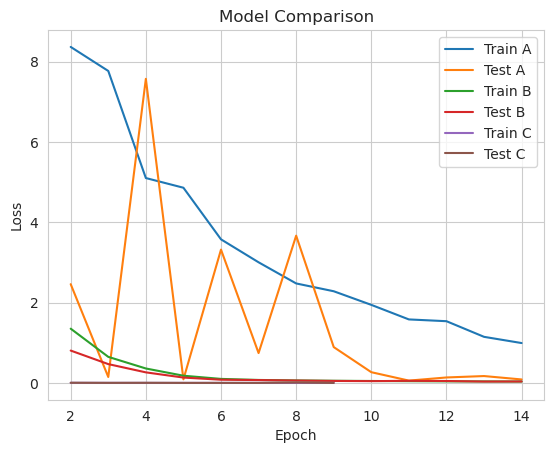

In [33]:
# Visualización
plt.figure()

sns.lineplot(x=range(2,len(train_A)), y=train_A[2:], label="Train A")
sns.lineplot(x=range(2,len(test_A)),  y=test_A[2:],  label="Test A")

sns.lineplot(x=range(2,len(train_B)), y=train_B[2:], label="Train B")
sns.lineplot(x=range(2,len(test_B)),  y=test_B[2:],  label="Test B")

sns.lineplot(x=range(2,len(train_C)), y=train_C[2:], label="Train C")
sns.lineplot(x=range(2,len(test_C)),  y=test_C[2:],  label="Test C")

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [34]:
mae_A = evaluate_model(model_A, test_loader, U0_mean, U0_std)
mae_B = evaluate_model(model_B, test_loader, U0_mean, U0_std)
mae_C = evaluate_model(model_C, test_loader, U0_mean, U0_std)

print("MAE Modelo A:", mae_A)
print("MAE Modelo B:", mae_B)
print("MAE Modelo C:", mae_C)

MAE Modelo A: 8.844115323144361
MAE Modelo B: 4.370892987737828
MAE Modelo C: 0.33851151852573125


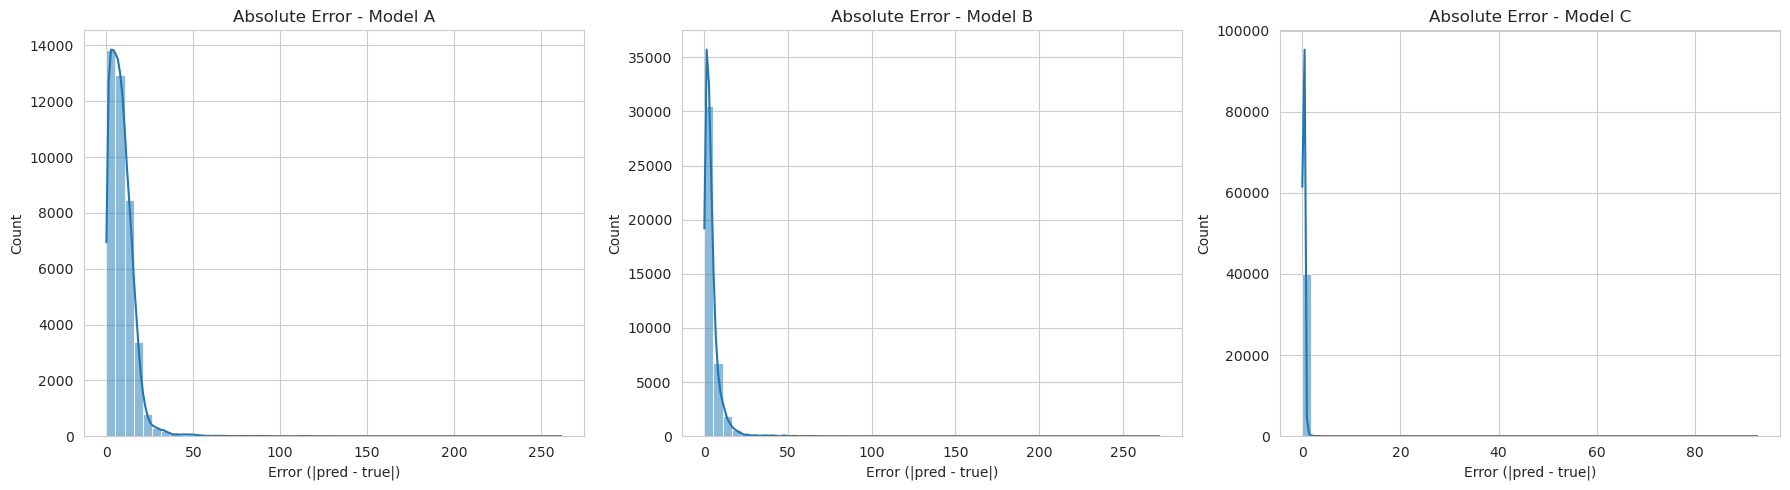

In [35]:
# === Error absoluto ===

def get_errors(model, loader):
    model.eval()

    preds_list   = []
    targets_list = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico

            preds_list.append(preds.cpu())
            targets_list.append(targets.cpu())

    preds   = torch.cat(preds_list).numpy()
    targets = torch.cat(targets_list).numpy()

    # desnormalizar solo las predicciones
    preds = preds * U0_std + U0_mean

    abs_errors = np.abs(preds - targets)

    return abs_errors


abs_err_A = get_errors(model_A, test_loader)
abs_err_B = get_errors(model_B, test_loader)
abs_err_C = get_errors(model_C, test_loader)


# === Plot ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(abs_err_A, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Absolute Error - Model A")
axes[0].set_xlabel("Error (|pred - true|)")

sns.histplot(abs_err_B, bins=50, kde=True, ax=axes[1])
axes[1].set_title("Absolute Error - Model B")
axes[1].set_xlabel("Error (|pred - true|)")

sns.histplot(abs_err_C, bins=50, kde=True, ax=axes[2])
axes[2].set_title("Absolute Error - Model C")
axes[2].set_xlabel("Error (|pred - true|)")

plt.tight_layout()
plt.show()

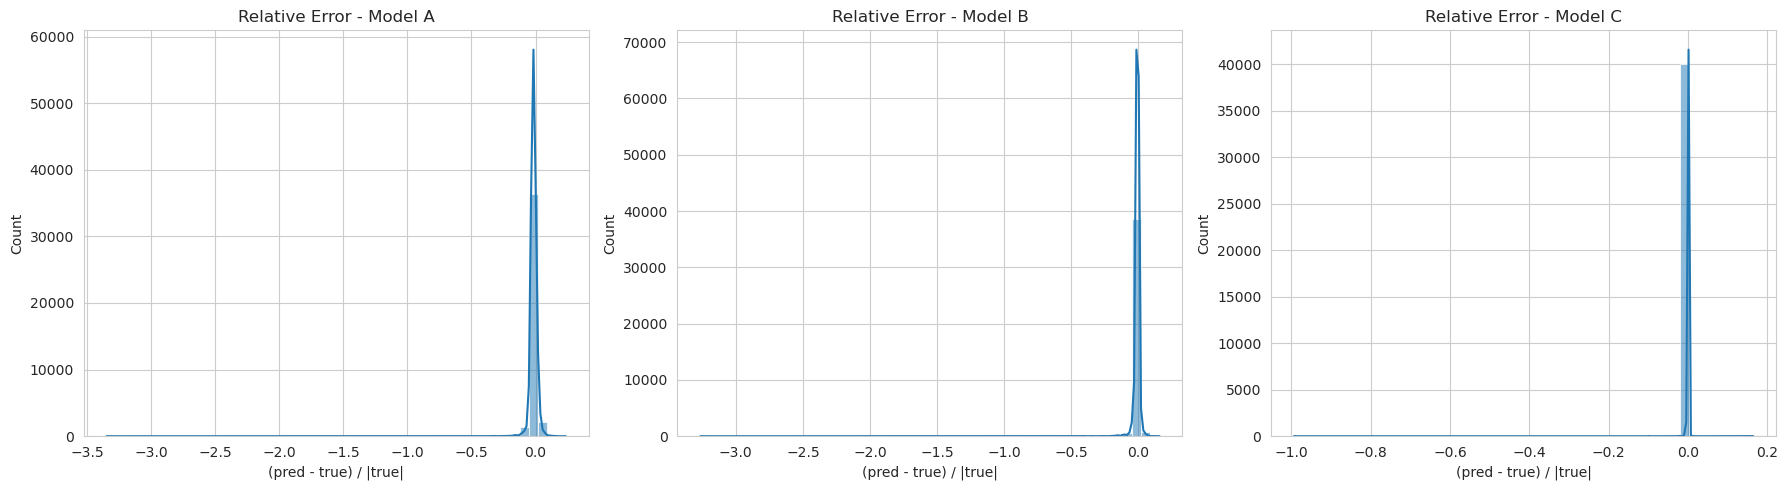

In [36]:
# === Error relativo ===

def get_relative_errors(model, loader):
    model.eval()

    preds_list   = []
    targets_list = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico

            preds_list.append(preds.cpu())
            targets_list.append(targets.cpu())

    preds   = torch.cat(preds_list).numpy()
    targets = torch.cat(targets_list).numpy()

    # desnormalizar solo las predicciones
    preds = preds * U0_std + U0_mean

    # evitar división por cero (no debería pasar, pero buena práctica)
    rel_errors = (preds - targets) / (np.abs(targets) + 1e-8)

    return rel_errors


rel_err_A = get_relative_errors(model_A, test_loader)
rel_err_B = get_relative_errors(model_B, test_loader)
rel_err_C = get_relative_errors(model_C, test_loader)

# === Plot ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rel_err_A, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Relative Error - Model A")
axes[0].set_xlabel("(pred - true) / |true|")

sns.histplot(rel_err_B, bins=50, kde=True, ax=axes[1])
axes[1].set_title("Relative Error - Model B")
axes[1].set_xlabel("(pred - true) / |true|")

sns.histplot(rel_err_C, bins=50, kde=True, ax=axes[2])
axes[2].set_title("Relative Error - Model C")
axes[2].set_xlabel("(pred - true) / |true|")

plt.tight_layout()
plt.show()

In [37]:
def evaluate_errors(model, loader):
    model.eval()

    preds_list   = []
    targets_list = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico

            preds_list.append(preds.cpu())
            targets_list.append(targets.cpu())

    preds   = torch.cat(preds_list).numpy()
    targets = torch.cat(targets_list).numpy()

    # desnormalizar solo las predicciones
    preds = preds * U0_std + U0_mean

    abs_error = np.abs(preds - targets)
    rel_error = abs_error / (np.abs(targets) + 1e-8)

    return abs_error, rel_error


# evaluar ambos modelos
abs_A, rel_A = evaluate_errors(model_A, test_loader)
abs_B, rel_B = evaluate_errors(model_B, test_loader)
abs_C, rel_C = evaluate_errors(model_C, test_loader)

# función para imprimir stats
def print_stats(name, abs_err, rel_err):
    print(f"\n {name}")

    print("Error absoluto:")
    print(f"   mean = {abs_err.mean():.4f}")
    print(f"   std  = {abs_err.std():.4f}")

    print("Error relativo:")
    print(f"   mean = {rel_err.mean():.6f}")
    print(f"   std  = {rel_err.std():.6f}")


# resultados
print_stats("Modelo A", abs_A, rel_A)
print_stats("Modelo B", abs_B, rel_B)
print_stats("Modelo C", abs_C, rel_C)


 Modelo A
Error absoluto:
   mean = 8.8441
   std  = 7.8094
Error relativo:
   mean = 0.022666
   std  = 0.038035

 Modelo B
Error absoluto:
   mean = 4.3709
   std  = 6.2725
Error relativo:
   mean = 0.011554
   std  = 0.033526

 Modelo C
Error absoluto:
   mean = 0.3385
   std  = 0.6464
Error relativo:
   mean = 0.000883
   std  = 0.006012


In [39]:
def evaluate_errors_physical(model, loader):
    model.eval()

    preds_list   = []
    targets_list = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico

            preds_list.append(preds.cpu())
            targets_list.append(targets.cpu())

    preds   = torch.cat(preds_list).numpy()
    targets = torch.cat(targets_list).numpy()

    # desnormalizar solo las predicciones
    preds_real   = preds * U0_std + U0_mean
    targets_real = targets  # ya está en Hartrees

    abs_error = np.abs(preds_real - targets_real)
    rel_error = abs_error / (np.abs(targets_real) + 1e-8)

    return abs_error, rel_error


# evaluar ambos modelos
abs_phys_A, rel_phys_A = evaluate_errors_physical(model_A, test_loader)
abs_phys_B, rel_phys_B = evaluate_errors_physical(model_B, test_loader)
abs_phys_C, rel_phys_C = evaluate_errors_physical(model_C, test_loader)


# función para imprimir stats
def print_stats_physical(name, abs_err, rel_err):
    print(f"\n {name}")

    print("Error absoluto físico:")
    print(f"   mean = {abs_err.mean():.4f}")
    print(f"   std  = {abs_err.std():.4f}")

    print("Error relativo físico:")
    print(f"   mean = {rel_err.mean():.6f}")
    print(f"   std  = {rel_err.std():.6f}")


# resultados
print_stats_physical("Modelo A", abs_phys_A, rel_phys_A)
print_stats_physical("Modelo B", abs_phys_B, rel_phys_B)
print_stats_physical("Modelo C", abs_phys_C, rel_phys_C)


 Modelo A
Error absoluto físico:
   mean = 8.8441
   std  = 7.8094
Error relativo físico:
   mean = 0.022666
   std  = 0.038035

 Modelo B
Error absoluto físico:
   mean = 4.3709
   std  = 6.2725
Error relativo físico:
   mean = 0.011554
   std  = 0.033526

 Modelo C
Error absoluto físico:
   mean = 0.3385
   std  = 0.6464
Error relativo físico:
   mean = 0.000883
   std  = 0.006012


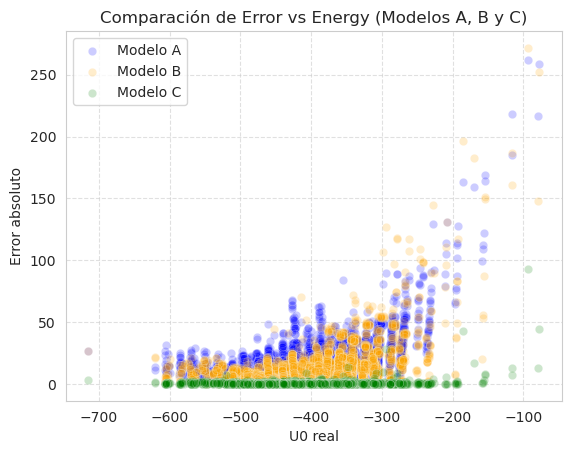

In [40]:
def get_physical_predictions(model, loader):
    model.eval()

    preds_list   = []
    targets_list = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico

            preds_list.append(preds.cpu())
            targets_list.append(targets.cpu())

    preds   = torch.cat(preds_list).numpy()
    targets = torch.cat(targets_list).numpy()

    # desnormalizar solo las predicciones
    preds_real   = preds * U0_std + U0_mean
    targets_real = targets  # ya está en Hartrees

    abs_error = np.abs(preds_real - targets_real)

    return preds_real, targets_real, abs_error


preds_real_A, targets_real_A, abs_error_A = get_physical_predictions(model_A, test_loader)
preds_real_B, targets_real_B, abs_error_B = get_physical_predictions(model_B, test_loader)
preds_real_C, targets_real_C, abs_error_C = get_physical_predictions(model_C, test_loader)


# Scatter para el Modelo A
sns.scatterplot(x=targets_real_A, y=abs_error_A, alpha=0.2, label="Modelo A", color="blue")

# Scatter para el Modelo B (se encimará al anterior)
sns.scatterplot(x=targets_real_B, y=abs_error_B, alpha=0.2, label="Modelo B", color="orange")

# Scatter para el Modelo C (se encimará al anterior)
sns.scatterplot(x=targets_real_C, y=abs_error_C, alpha=0.2, label="Modelo C", color="green")

# Configuración de etiquetas y estilo
plt.xlabel("U0 real")
plt.ylabel("Error absoluto")
plt.title("Comparación de Error vs Energy (Modelos A, B y C)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


=== Modelo A ===
          abs_error              rel_error          
               mean          var      mean       var
n_atoms                                             
3        261.716175          NaN  2.801744       NaN
4        210.904603  4573.814554  2.112563  3.046068
5        124.778531  2420.337231  0.623539  0.201654
6        114.963199  2875.737703  0.613927  0.400106
7        108.830209  2961.987010  0.613095  0.273583
8         67.677492  2771.878770  0.373557  0.399101
9         33.004657   643.884462  0.104407  0.012727
10        26.309991   481.982326  0.084368  0.011546
11        17.357559   197.047262  0.048562  0.003002
12        14.115262   176.928343  0.039948  0.003515
13        11.428025    90.603355  0.030233  0.001167
14        10.044427    68.723961  0.026117  0.000859
15         9.343189    46.099878  0.023395  0.000430
16         8.746068    36.441026  0.021638  0.000296
17         8.739757    33.885596  0.021354  0.000235
18         8.339996    29.62

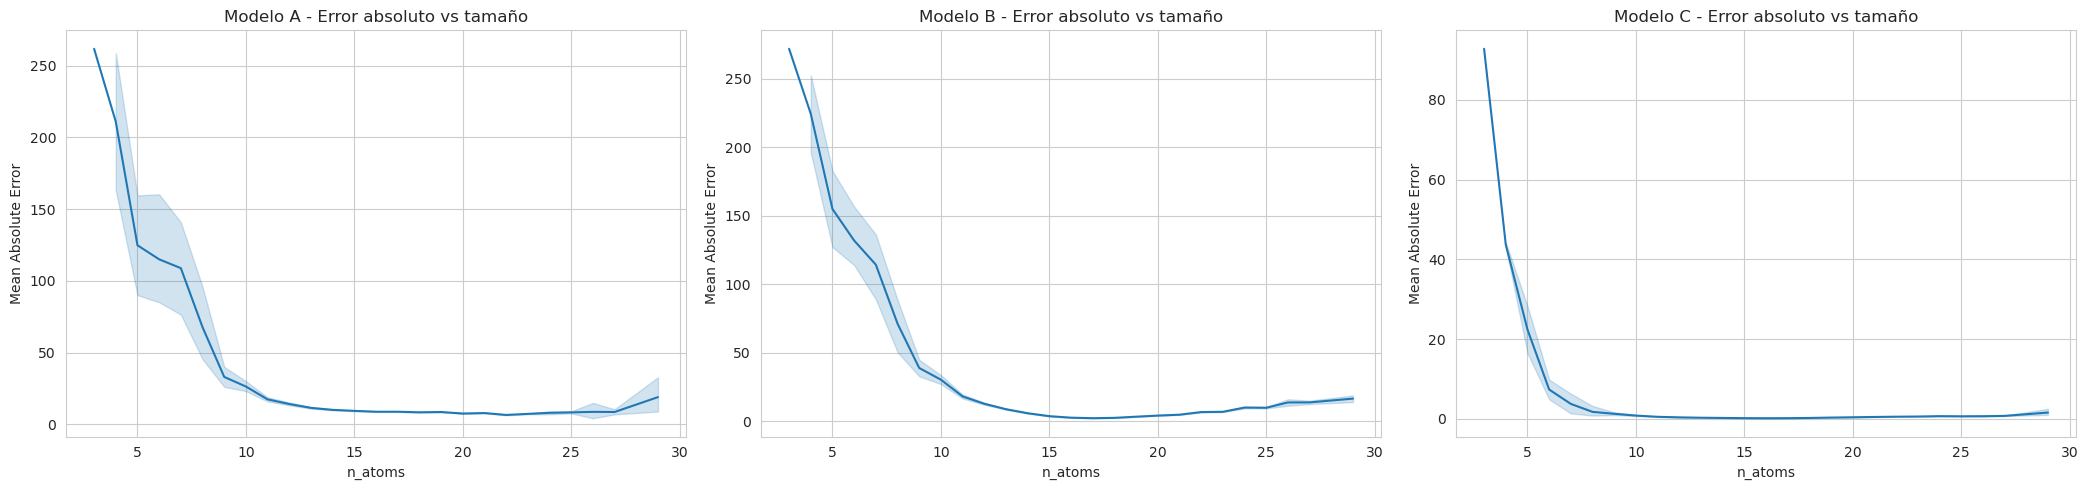

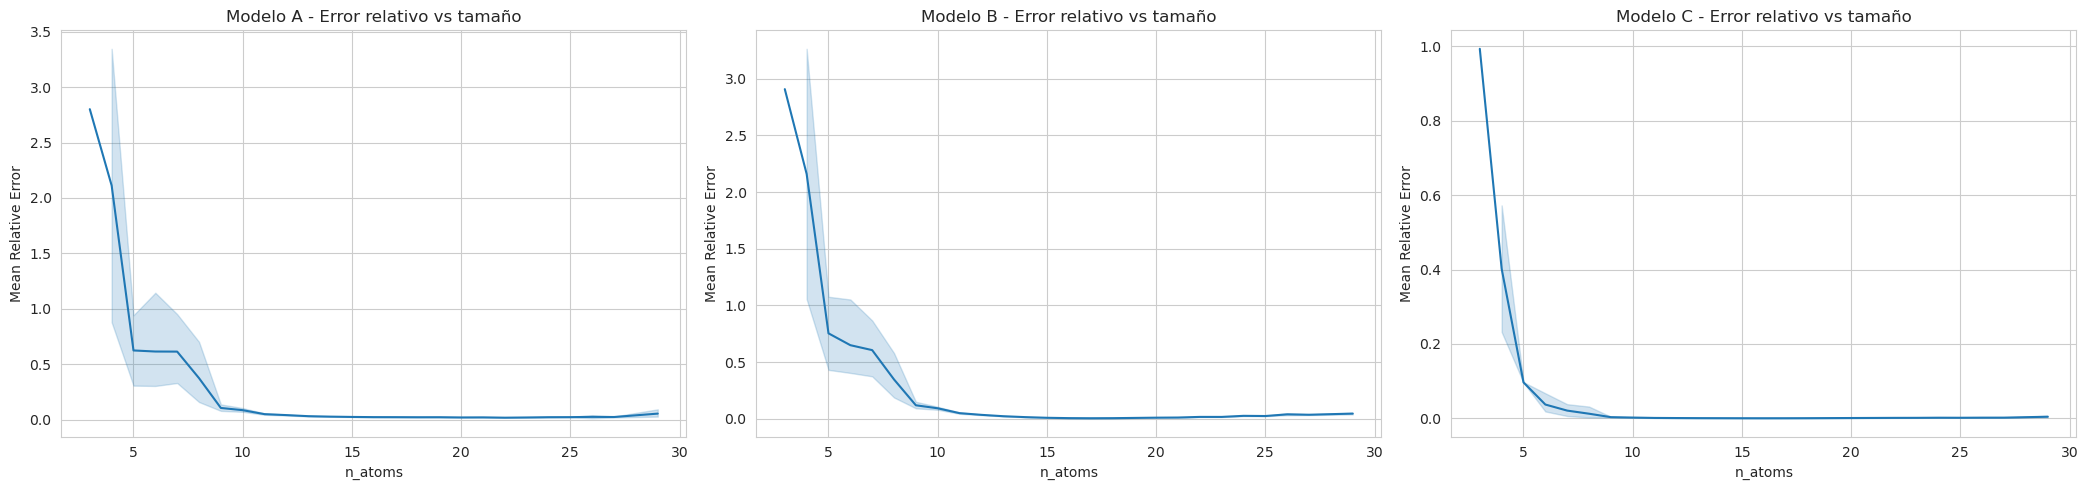

In [41]:
# Definir la función para recolectar errores por tamaño
def collect_errors_by_size(model, loader):
    model.eval()

    sizes      = []
    abs_errors = []
    rel_errors = []

    with torch.no_grad():
        for batch in loader:
            preds   = model(batch)
            targets = torch.stack([m["U0"] for m in batch]).to(DEVICE)  # 🔥 físico

            preds   = preds.cpu().numpy()
            targets = targets.cpu().numpy()

            # desnormalizar solo las predicciones
            preds_real   = preds * U0_std + U0_mean
            targets_real = targets  # ya está en Hartrees

            for i, mol in enumerate(batch):
                n_atoms = len(mol["Z"])

                abs_err = abs(preds_real[i] - targets_real[i])
                rel_err = abs_err / (abs(targets_real[i]) + 1e-8)

                sizes.append(n_atoms)
                abs_errors.append(abs_err)
                rel_errors.append(rel_err)

    df = pd.DataFrame({
        "n_atoms":   sizes,
        "abs_error": abs_errors,
        "rel_error": rel_errors
    })

    return df


# recolectar datos
df_A = collect_errors_by_size(model_A, test_loader)
df_B = collect_errors_by_size(model_B, test_loader)
df_C = collect_errors_by_size(model_C, test_loader)

# agrupar estadísticas
stats_A = df_A.groupby("n_atoms").agg({
    "abs_error": ["mean", "var"],
    "rel_error": ["mean", "var"]
})

stats_B = df_B.groupby("n_atoms").agg({
    "abs_error": ["mean", "var"],
    "rel_error": ["mean", "var"]
})

stats_C = df_C.groupby("n_atoms").agg({
    "abs_error": ["mean", "var"],
    "rel_error": ["mean", "var"]
})


# PRINT DETALLADO
print("\n=== Modelo A ===")
print(stats_A)

print("\n=== Modelo B ===")
print(stats_B)

print("\n=== Modelo C ===")
print(stats_C)


# =========================
# PLOTS
# =========================

# === Error absoluto ===
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.lineplot(data=df_A, x="n_atoms", y="abs_error", estimator="mean", ax=axes[0])
axes[0].set_title("Modelo A - Error absoluto vs tamaño")
axes[0].set_ylabel("Mean Absolute Error")

sns.lineplot(data=df_B, x="n_atoms", y="abs_error", estimator="mean", ax=axes[1])
axes[1].set_title("Modelo B - Error absoluto vs tamaño")
axes[1].set_ylabel("Mean Absolute Error")

sns.lineplot(data=df_C, x="n_atoms", y="abs_error", estimator="mean", ax=axes[2])
axes[2].set_title("Modelo C - Error absoluto vs tamaño")
axes[2].set_ylabel("Mean Absolute Error")

plt.tight_layout()
plt.show()

# === Error relativo ===
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.lineplot(data=df_A, x="n_atoms", y="rel_error", estimator="mean", ax=axes[0])
axes[0].set_title("Modelo A - Error relativo vs tamaño")
axes[0].set_ylabel("Mean Relative Error")

sns.lineplot(data=df_B, x="n_atoms", y="rel_error", estimator="mean", ax=axes[1])
axes[1].set_title("Modelo B - Error relativo vs tamaño")
axes[1].set_ylabel("Mean Relative Error")

sns.lineplot(data=df_C, x="n_atoms", y="rel_error", estimator="mean", ax=axes[2])
axes[2].set_title("Modelo C - Error relativo vs tamaño")
axes[2].set_ylabel("Mean Relative Error")

plt.tight_layout()
plt.show()

### Entrenamiento de modelos para exportación

In [42]:
# Imports adicionales para entrenamiento completo
import time
import json

In [43]:
# Dataset completo — sin split, entrenamiento sobre todo QM9
all_U0 = np.array([parse_xyz(f)[2] for f in DATA_PATH.glob("*.xyz")])

U0_mean = all_U0.mean()
U0_std  = all_U0.std()

print(f"Total moléculas: {len(all_U0):,}")
print(f"U0 mean: {U0_mean:.4f} | U0 std: {U0_std:.4f}")

dataset = QM9Dataset(DATA_PATH, mean=U0_mean, std=U0_std)

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

print(f"Total batches por epoch: {len(train_loader):,}")

Total moléculas: 133,885
U0 mean: -411.5440 | U0 std: 40.0601
Total batches por epoch: 4,184


In [50]:
# Direccion de guardado de modelos
SAVE_DIR = Path("/home/colmanok/Code/QM9/models")

# Guardado
def save_model(model, name, train_losses, U0_mean, U0_std):
    path = SAVE_DIR / f"{name}.pt"

    torch.save({
        "model_state_dict": model.state_dict(),
        "model_class":      model.__class__.__name__,
        "train_losses":     train_losses,
        "U0_mean":          U0_mean,
        "U0_std":           U0_std,
    }, path)

    print(f"Guardado: {path}")

In [51]:
# Entrenamiento sin test set
def train_model_full(model, train_loader, epochs=30, lr=5e-4):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            preds   = model(batch)
            targets = torch.stack([m["U0_norm"] for m in batch]).to(DEVICE)

            loss = loss_fn(preds, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        elapsed = time.time() - t0
        print(f"Epoch {epoch+1}/{epochs}: Loss={train_loss:.4f} | {elapsed:.1f}s")

    return model, train_losses

In [ ]:
# Entrenar y exportar — Modelo A
print("=== Modelo A ===")
model_A = KernelModel()
model_A, train_A = train_model_full(model_A, train_loader, epochs=10, lr=5e-4)
save_model(model_A, "model_A_kernel", train_A, U0_mean, U0_std)


In [ ]:
# Entrenar y exportar — Modelo B
print("\n=== Modelo B ===")
model_B = KernelModelFlexible()
model_B, train_B = train_model_full(model_B, train_loader, epochs=10, lr=5e-4)
save_model(model_B, "model_B_kernel_flexible", train_B, U0_mean, U0_std)


In [53]:
# Entrenar y exportar — Modelo C
print("\n=== Modelo C ===")
model_C = SchNet(hidden_dim=128, n_basis=64, n_interactions=3, r_cutoff=10.0)
model_C, train_C = train_model_full(model_C, train_loader, epochs=5, lr=5e-4)
save_model(model_C, "model_C_schnet", train_C, U0_mean, U0_std)


=== Modelo C ===
Epoch 1/5: Loss=0.0323 | 648.2s
Epoch 2/5: Loss=0.0056 | 602.1s
Epoch 3/5: Loss=0.0043 | 552.2s
Epoch 4/5: Loss=0.0029 | 490.9s
Epoch 5/5: Loss=0.0018 | 483.0s
Guardado: /home/colmanok/Code/QM9/models/model_C_schnet.pt
